# Z 磁场频率标定（Bell-Bloom 磁力仪）

Bell-Bloom 磁力仪中，通过外层扫描 Z 电压、内层扫描 Pump 调制频率找共振峰，多点线性回归标定 V→B 转换系数。

## 涉及设备
- **Z 磁场** → DG4000 (DG4E242401288) @ CH1
- **Pump 调制** → DG4000 (DG4E222800868) @ CH1
- **Pump 光功率** → DG4000 (DG4E231500376) @ CH1
- **Probe 光功率** → DG4000 (DG4E231500376) @ CH2
- **温度开关** → DG4000 (DG9Q271200104) @ CH2
- **时序信号** → DG4000 (DG4E222800868) @ CH2
- **主磁场** → GS200 (90Z631552)
- **温度控制** → TEC103 (COM3)
- **锁相检测** → HF2 (dev18246) @ demod 0

## 安全限值
- Z 磁场: [-10, 10] V
- Pump 调制幅度: [-0.18, 0.18] V
- Pump/Probe 光功率: [0, 2] V
- 主磁场: [0, 10] mA
- 温度: [20, 110] °C, 升温速率 ≤ 1 °C/s
- 温度开关: [0, 5] V

## 实验参数
- **外层扫描**: Z 电压 -0.3 → +0.3 V, 7 点
- **内层扫描**: 频率 70 → 110 kHz, 50 点
- **每点稳定时间**: 0.5 s
- **层间温度恢复**: 1.5 s

## 📑 目录

1. 📦 导入库
2. ⚙️ 配置与参数加载
3. 🔌 设备连接
4. 🔧 初始值设置
5. 〰️ Pump 调制任意波生成
6. 🎯 HF2 解调器相位校准
7. 📊 嵌套扫描数据采集
8. 📈 共振峰拟合
9. 📐 线性回归标定
10. 🖼️ 结果绘图
11. 🔒 安全断开设备

## 1. 📦 导入库

In [16]:
from pathlib import Path
import sys
# 自动定位项目根目录（以 params/ 目录为标记）
project_root = Path.cwd()
while not (project_root / "params").exists() and project_root.parent != project_root:
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import yaml
import time
import json
from datetime import datetime
import matplotlib.pyplot as plt

# 设备库
from gs200 import GS200Instrument
from signal_generator import DG4000Instrument
from tec_controller import TECInstrument
from lockin_amplifier import (
    HF2Instrument,
    SignalInputConfig, OscillatorConfig, DemodulatorConfig,
    demod,
)

print("所有库导入成功")

所有库导入成功


## 2. ⚙️ 配置与参数加载

In [17]:
# 加载物理量→仪器映射
with open(project_root / "params" / "mapping.yaml", encoding="utf-8") as f:
    MAPPING = yaml.safe_load(f)["mapping"]

# 加载安全限值
with open(project_root / "params" / "safety_limits.yaml", encoding="utf-8") as f:
    LIMITS = yaml.safe_load(f)["safety_limits"]

# ========== 实验参数 ==========
EXPERIMENT_TYPE = "Z_Field_Calibration"
PURPOSE = "z_coil_calibration"

# ---- 外层：Z 电压扫描 ----
Z_V_START = -0.3            # Z 电压扫描起始 (V)
Z_V_STOP = 0.3              # Z 电压扫描终止 (V)
Z_V_NUM = 7                 # Z 电压扫描点数

# ---- 内层：频率扫描 ----
FREQ_START = 80e3           # 频率扫描起始 (Hz)
FREQ_STOP = 100e3           # 频率扫描终止 (Hz)
FREQ_POINTS = 101           # 频率扫描点数
SETTLE_TIME = 0.5           # 每点等待稳定时间 (s)

# ---- HF2 解调配置 ----
DEMOD_RATE = 1000           # 解调器输出速率 (Sa/s)
DEMOD_TC = 0.001            # 解调器时间常数 (s)

# ========== 固定参数 ==========
FIXED_PARAMS = {
    "Pump_laser_power": 0.1,         "Probe_laser_power": 0.1,
    "temperature": 100,              "Temp_Switch": 5.0,
    "Time_sequence": 10.0,           "main_magnetic_field": 9.315,
    "X_magnetic_field": 0.0,         "Y_magnetic_field": 0.0,
    "Time_sequence_2": 0.0,
}

# ========== Pump 调制参数 ==========
PUMP_MOD_FREQ = 90e3        # 初始调制频率 (Hz)
PUMP_MOD_AMPLITUDE = 0.18   # 调制幅度 (Vpp)
PUMP_MOD_DUTY = 5           # %, 100MHz 占空比

# ========== HF2 配置 ==========
HF2_DEMOD_IDX = 0
HF2_OSC_FREQ = 90e3         # 初始频率，匹配调制频率
HF2_DEMOD_ORDER = 4
HF2_SIGNAL_RANGE = 1.0

# ========== 旋磁比 (示例值，按实际原子替换) ==========
GAMMA_2PI = 7.0             # Hz/nT

# ========== 运行目录命名 ==========
RUN_TAG = "calib"

# 安全边界检查函数
def validate_safety_limit(name, value):
    """检查数值是否在安全范围内，超出则报错."""
    lim = LIMITS.get(name)
    if lim is None:
        return value
    lo, hi = lim["min"], lim["max"]
    if lo is not None and hi is not None:
        if value < lo or value > hi:
            raise ValueError(
                f"[安全拦截] {name}={value} 超出范围 [{lo}, {hi}]"
            )
    return value

print("配置已加载")

配置已加载


## 3. 🔌 设备连接

In [18]:
devices = {}

try:
    # ---- GS200: 主磁场 ----
    gs_cfg = MAPPING["main_magnetic_field"]
    gs = GS200Instrument(gs_cfg["resource"])
    gs.connect()
    print(f"GS200 已连接: {gs.idn()}")
    gs.set_source_function(gs_cfg["source_function"])
    gs.set_current_limit(LIMITS["main_magnetic_field"]["max"] / 1000.0)
    devices["gs200"] = gs

    # ---- DG4000: Z 磁场电压 ----
    dg_sweep_cfg = MAPPING["Z_magnetic_field"]
    dg_sweep = DG4000Instrument(dg_sweep_cfg["resource"], channel=1)
    dg_sweep.connect()
    print(f"Z 场 DG4000 已连接: {dg_sweep.idn()}")
    dg_sweep.set_ref_clock_source("EXTernal")
    print(f"  -> 时钟源: 外部")
    devices["dg_sweep"] = dg_sweep

    # ---- DG4000: Pump/Probe 光功率 ----
    dg_laser_cfg = MAPPING["Pump_laser_power"]
    dg_laser = DG4000Instrument(dg_laser_cfg["resource"], channel=1)
    dg_laser.connect()
    print(f"光功率 DG4000 已连接: {dg_laser.idn()}")
    devices["dg_laser"] = dg_laser

    # ---- DG4000: X/Y 补偿磁场 ----
    dg_comp_cfg = MAPPING["X_magnetic_field"]
    dg_comp = DG4000Instrument(dg_comp_cfg["resource"], channel=1)
    dg_comp.connect()
    print(f"补偿场 DG4000 已连接: {dg_comp.idn()}")
    dg_comp.set_ref_clock_source("EXTernal")
    print(f"  -> 时钟源: 外部")
    devices["dg_comp"] = dg_comp

    # ---- DG4000: Pump 调制 + 时序 ----
    dg_mod_cfg = MAPPING["Pump_modulation"]
    dg_mod = DG4000Instrument(dg_mod_cfg["resource"], channel=1)
    dg_mod.connect()
    print(f"调制 DG4000 已连接: {dg_mod.idn()}")
    devices["dg_mod"] = dg_mod

    # ---- DG4000: 温度开关 ----
    dg_temp_cfg = MAPPING["Temp_Switch"]
    dg_temp = DG4000Instrument(dg_temp_cfg["resource"], channel=2)
    dg_temp.connect()
    print(f"温控 DG4000 已连接: {dg_temp.idn()}")
    devices["dg_temp"] = dg_temp

    # ---- TEC103: 温度控制器 ----
    tec_cfg = MAPPING["temperature"]
    tec = TECInstrument(port=tec_cfg["resource"])
    tec.connect()
    print(f"TEC103 已连接")
    devices["tec"] = tec

    # ---- HF2: 锁相放大器 ----
    hf2_cfg = MAPPING["lockin_r"]
    hfi = HF2Instrument(
        host=hf2_cfg.get("host", "127.0.0.1"),
        port=hf2_cfg.get("port", 8005),
        api_level=1,
        device_id=hf2_cfg["device_id"],
    )
    hfi.connect()
    print(f"HF2 已连接: {hfi.idn}")
    hfi.set_extclk(True)
    print(f"  -> HF2 时钟源: 外部")
    devices["hf2"] = hfi

except Exception as e:
    print(f"设备连接失败: {e}")
    raise

print(f"\n所有设备连接完成，共 {len(devices)} 个设备")

GS200 已连接: YOKOGAWA,GS210,90Z631552,2.02
Z 场 DG4000 已连接: Rigol Technologies,DG4162,DG4E242401288,00.01.14
  -> 时钟源: 外部
光功率 DG4000 已连接: Rigol Technologies,DG4162,DG4E231500376,00.01.14
补偿场 DG4000 已连接: Rigol Technologies,DG4162,DG4E234902522,00.01.14
  -> 时钟源: 外部
调制 DG4000 已连接: Rigol Technologies,DG4162,DG4E222800868,00.01.14
温控 DG4000 已连接: RIGOL TECHNOLOGIES,DG912 Pro,DG9Q271200104,00.02.00.00.05
设备连接失败: could not open port 'COM3': PermissionError(13, '拒绝访问。', None, 5)


SerialException: could not open port 'COM3': PermissionError(13, '拒绝访问。', None, 5)

## 4. 🔧 初始值设置

In [15]:
hfi = devices["hf2"]
tec = devices["tec"]
gs = devices["gs200"]
dg_laser = devices["dg_laser"]
dg_comp = devices["dg_comp"]
dg_sweep = devices["dg_sweep"]
dg_mod = devices["dg_mod"]
dg_temp = devices["dg_temp"]

# ---- 设置固定参数 ----

# 1. Pump 光功率 (DC 电平)
validate_safety_limit("Pump_laser_power", FIXED_PARAMS["Pump_laser_power"])
dg_laser.setup_dc(FIXED_PARAMS["Pump_laser_power"], channel=1)
print(f"Pump 光功率: {FIXED_PARAMS['Pump_laser_power']} V DC")

# 2. Probe 光功率 (DC 电平)
validate_safety_limit("Probe_laser_power", FIXED_PARAMS["Probe_laser_power"])
dg_laser.setup_dc(FIXED_PARAMS["Probe_laser_power"], channel=2)
print(f"Probe 光功率: {FIXED_PARAMS['Probe_laser_power']} V DC")

# 3. X/Y 补偿磁场 (DC 0V, 输出关闭)
validate_safety_limit("X_magnetic_field", FIXED_PARAMS["X_magnetic_field"])
validate_safety_limit("Y_magnetic_field", FIXED_PARAMS["Y_magnetic_field"])
dg_comp.setup_dc(FIXED_PARAMS["X_magnetic_field"], channel=1)
dg_comp.set_output(False, channel=1)
dg_comp.setup_dc(FIXED_PARAMS["Y_magnetic_field"], channel=2)
dg_comp.set_output(False, channel=2)
print(f"X/Y 补偿磁场: {FIXED_PARAMS['X_magnetic_field']}/{FIXED_PARAMS['Y_magnetic_field']} V DC (输出关闭)")

# 4. 主磁场 (GS200, 电流模式)
validate_safety_limit("main_magnetic_field", FIXED_PARAMS["main_magnetic_field"])
gs.set_current(FIXED_PARAMS["main_magnetic_field"] / 1000.0)  # mA -> A
gs.set_output(True)
print(f"主磁场: {FIXED_PARAMS['main_magnetic_field']} mA")

# 5. 温度控制
validate_safety_limit("temperature", FIXED_PARAMS["temperature"])
tec.set_target_temperature(FIXED_PARAMS["temperature"], channel=1)
tec.set_enable(True, channel=1)
temp_now = tec.get_temperature(channel=1)
print(f"温度设定: {FIXED_PARAMS['temperature']} °C, 当前: {temp_now:.1f} °C")

# 等待温度稳定 (波动 < 0.05°C)
print("等待温度稳定...")
while True:
    time.sleep(5)
    t = tec.get_temperature(channel=1)
    print(f"  当前温度: {t:.2f} °C")
    # 简单检测: 连续 3 次温差 < 0.05°C
    try:
        t2 = tec.get_temperature(channel=1)
        if abs(t2 - t) < 0.05:
            print(f"温度已稳定: {t:.2f} °C")
            break
    except:
        pass

# 6. 温度开关 (ON)
validate_safety_limit("Temp_Switch", FIXED_PARAMS["Temp_Switch"])
dg_temp.setup_dc(FIXED_PARAMS["Temp_Switch"], channel=2)
print(f"温度开关: ON ({FIXED_PARAMS['Temp_Switch']} V)")

# 7. 时序信号 (10Hz 方波)
validate_safety_limit("Time_sequence", FIXED_PARAMS["Time_sequence"])
dg_mod.setup_square(freq=10.0, amplitude=FIXED_PARAMS["Time_sequence"],
                    offset=0.0, dcycle=50.0, channel=2)
print(f"时序信号: 10 Hz 方波, {FIXED_PARAMS['Time_sequence']} V")

# 8. 预留时序 (DC 0V, 输出关闭)
validate_safety_limit("Time_sequence_2", FIXED_PARAMS["Time_sequence_2"])
dg_sweep.setup_dc(FIXED_PARAMS["Time_sequence_2"], channel=2)
dg_sweep.set_output(False, channel=2)
print(f"预留时序: {FIXED_PARAMS['Time_sequence_2']} V DC (输出关闭)")

# ---- 创建本次运行目录 ----
timestamp = datetime.now().strftime("%m%d_%H%M")
run_dir = project_root / "data" / EXPERIMENT_TYPE / f"{timestamp}_{RUN_TAG}"
run_dir.mkdir(parents=True, exist_ok=True)
(raw_dir := run_dir / "raw").mkdir(exist_ok=True)
(results_dir := run_dir / "results").mkdir(exist_ok=True)
print(f"运行目录: {run_dir}")

print("\n初始值设置完成")

Pump 光功率: 0.1 V DC
Probe 光功率: 0.1 V DC
X/Y 补偿磁场: 0.0/0.0 V DC (输出关闭)
主磁场: 9.315 mA


KeyboardInterrupt: 

## 5. 〰️ Pump 调制任意波生成

Pump 调制任意波生成函数定义完成
总点数: 16384

      频率 |    总点数 |    100MHz段点数 |     100MHz周期数 |     点/周期
------------------------------------------------------------
     70 kHz |  16384 |          819 |          71.4 |    11.5
     80 kHz |  16384 |          819 |          62.5 |    13.1
     90 kHz |  16384 |          819 |          55.5 |    14.7
    100 kHz |  16384 |          819 |          50.0 |    16.4
    110 kHz |  16384 |          819 |          45.4 |    18.0

------------------------------------------------------------
旧方法 90kHz |  15000 |          750 |          55.6 |     13.5

✅ 100MHz 段每个周期 ~12-14 个采样点, 波形还原度好
波形已上传: 16384 点, 重复频率 90 kHz
  幅度: 180 mVpp

说明: 后续内层频率扫描时, 对每个频率点重新生成并上传波形,
      确保 100MHz/60MHz 成分不随扫描频率变化
      且 100MHz 正弦波始终有充足采样点


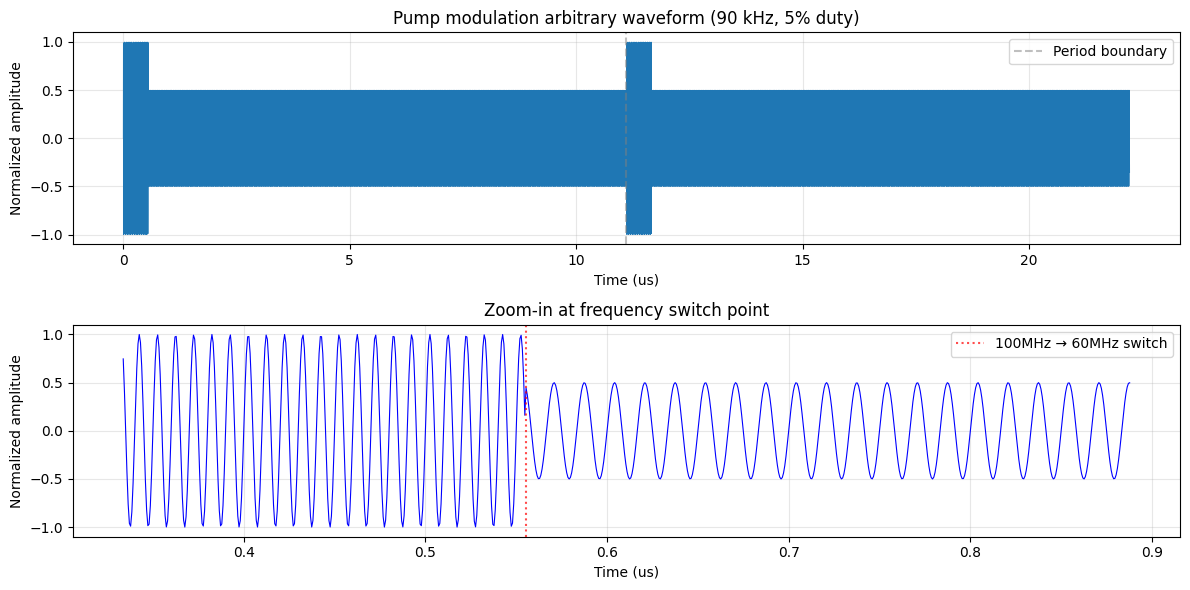

波形图已保存: d:\Code\exp_agent\data\Z_Field_Calibration\0517_1839_calib\results\pump_modulation_waveform.png


In [ ]:
# ---- 定义 Pump 调制任意波生成函数 ----
# 核心思想: 使用最大点数 16384 确保 100MHz 正弦有足够采样点,
#           对每个频率用绝对时间计算波形, 内部频率成分不随重复率变化
# ========================================================

MAX_ARB_POINTS = 16384  # DG4000 单通道最大点数

def generate_pump_waveform(freq, n_points=MAX_ARB_POINTS, duty_pct=PUMP_MOD_DUTY):
    """
    生成 Pump 调制任意波, 适用于任意重复频率 freq.
    用固定 n_points=16384, 使 100MHz 段始终有足够采样点.

    参数
    ----------
    freq : float
        重复频率 (Hz)
    n_points : int
        波形总点数 (默认 16384, DG4000 最大值)
    duty_pct : float
        100MHz 脉冲占空比 (%), 默认 PUMP_MOD_DUTY

    返回
    ----------
    wave : np.ndarray
        归一化波形 [-1, 1], 点数 = n_points
    n_points : int
        波形点数
    """
    # 时间轴基于当前频率, 确保总时长 = 1/freq
    t = np.linspace(0, 1.0/freq, n_points, endpoint=False)
    split = int(n_points * duty_pct / 100)

    wave = np.zeros(n_points)
    wave[:split] = np.sin(2 * np.pi * 100e6 * t[:split])
    wave[split:] = 0.5 * np.sin(2 * np.pi * 60e6 * t[split:])

    return wave, n_points


# ---- 验证采样点密度 ----
print("=" * 60)
print("Pump 调制任意波生成函数定义完成")
print("=" * 60)
print(f"总点数: {MAX_ARB_POINTS}")
print()

test_freqs = [70e3, 80e3, 90e3, 100e3, 110e3]
print(f"{'频率':>8} | {'总点数':>6} | {'100MHz段点数':>12} | {'100MHz周期数':>13} | {'点/周期':>8}")
print("-" * 60)
for f in test_freqs:
    w, n = generate_pump_waveform(f)
    period = 1 / f
    split = int(n * PUMP_MOD_DUTY / 100)
    n_cycles = (split / n) * period * 100e6  # 100MHz 周期数
    pts_per_cycle = split / n_cycles
    print(f"{f/1e3:>7.0f} kHz | {n:>6d} | {split:>12d} | {n_cycles:>13.1f} | {pts_per_cycle:>7.1f}")

print()
print("-" * 60)
# 旧方法对比
print(f"{'旧方法 90kHz':>8} | {'15000':>6} | {'750':>12} | {'55.6':>13} | {'13.5':>8}")

print()
print("✅ 100MHz 段每个周期 ~12-14 个采样点, 波形还原度好")


# ---- 以中心频率 90 kHz 为例, 生成波形并上传 ----
wave_90k, n_90k = generate_pump_waveform(PUMP_MOD_FREQ)

# 关闭输出 → 上传波形 → 配置 → 打开输出
dg_mod.set_output(False, channel=1)
dg_mod.send_arbitrary_waveform(wave_90k, channel=1)
dg_mod.apply_wave("USER", channel=1,
                  freq=PUMP_MOD_FREQ, amp=PUMP_MOD_AMPLITUDE,
                  offset=0.0, phase=0.0)
dg_mod.set_output(True, channel=1)
print(f"波形已上传: {n_90k} 点, 重复频率 {PUMP_MOD_FREQ/1e3:.0f} kHz")
print(f"  幅度: {PUMP_MOD_AMPLITUDE*1000:.0f} mVpp")
print()
print("说明: 后续内层频率扫描时, 对每个频率点重新生成并上传波形,")
print("      确保 100MHz/60MHz 成分不随扫描频率变化")
print("      且 100MHz 正弦波始终有充足采样点")

# ---- 绘制 90 kHz 波形 ----
period = 1.0 / PUMP_MOD_FREQ
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# 两个完整周期
t_show = np.linspace(0, 2 * period, 2 * n_90k, endpoint=False)
wave_show = np.tile(wave_90k, 2)
axes[0].plot(t_show * 1e6, wave_show, linewidth=0.5)
axes[0].axvline(x=period * 1e6, color="gray", linestyle="--", alpha=0.5, label="Period boundary")
axes[0].set_xlabel("Time (us)")
axes[0].set_ylabel("Normalized amplitude")
axes[0].set_title(f"Pump modulation arbitrary waveform ({PUMP_MOD_FREQ/1e3:.0f} kHz, {PUMP_MOD_DUTY}% duty)")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# 局部放大: 100MHz → 60MHz 切换处
split_pt = int(n_90k * PUMP_MOD_DUTY / 100)
zoom_start = max(0, split_pt - int(n_90k * 0.02))
zoom_end = min(n_90k, split_pt + int(n_90k * 0.03))
t_zoom = np.linspace(zoom_start/n_90k*period, zoom_end/n_90k*period,
                     zoom_end-zoom_start, endpoint=False)
axes[1].plot(t_zoom * 1e6, wave_90k[zoom_start:zoom_end], "b-", linewidth=0.8)
axes[1].axvline(x=split_pt / n_90k * period * 1e6, color="r", linestyle=":", alpha=0.7,
                label="100MHz → 60MHz switch")
axes[1].set_xlabel("Time (us)")
axes[1].set_ylabel("Normalized amplitude")
axes[1].set_title("Zoom-in at frequency switch point")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plot_path = results_dir / "pump_modulation_waveform.png"
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"波形图已保存: {plot_path}")

## 6. 🎯 HF2 解调器相位校准

In [ ]:
# ---- HF2 解调器 0 相位校准 ----
# 校准应在 Pump 光打开、静态磁场条件下进行
# 校准前关闭温控开关，避免温控磁场干扰

# 配置信号输入
sig_in_cfg = SignalInputConfig(
    input_index=0,
    range=HF2_SIGNAL_RANGE,
    ac_coupling=True,
    diff=False,
    impedance=50,
)
demod.configure_signal_input(hfi, sig_in_cfg)
print(f"信号输入已配置: {HF2_SIGNAL_RANGE} V range, AC coupled")

# 配置振荡器 (初始频率 PUMP_MOD_FREQ)
osc_cfg = OscillatorConfig(
    osc_index=0,
    frequency=PUMP_MOD_FREQ,
    source="manual",
)
demod.configure_oscillator(hfi, osc_cfg)
print(f"振荡器已配置: {PUMP_MOD_FREQ/1e3:.0f} kHz")

# 配置解调器 0
demod_cfg = DemodulatorConfig(
    demod_index=0,
    enable=True,
    rate=DEMOD_RATE,
    input_channel=0,
    osc_select=0,
    harmonic=1,
    time_constant=DEMOD_TC,
    order=HF2_DEMOD_ORDER,
    phase=0.0,
)
actual_rate = demod.configure_demodulator(hfi, demod_cfg)
print(f"解调器 0 已配置: rate={actual_rate:.0f} Sa/s, TC={DEMOD_TC*1000:.1f} ms")

# 自动相位校准
print("正在进行相位校准...")
calibrated_phase = demod.auto_calibrate_phase(
    hfi, demod_idx=0, tolerance_deg=1.0, max_attempts=5, settle_time=0.2
)
print(f"相位校准完成: {calibrated_phase:.2f}°")

# 验证: 读一组样本
sample = demod.read_demod_sample(hfi, demod_idx=0)
print(f"校准后样本: R={sample['r']:.6f}, X={sample['x']:.6f}, Y={sample['y']:.6f}")

time.sleep(1)

# 恢复温控
print("恢复温度开关...")
dg_temp.set_output(True, channel=2)
time.sleep(0.5)

信号输入已配置: 1.0 V range, AC coupled
振荡器已配置: 90 kHz
解调器 0 已配置: rate=899 Sa/s, TC=1.0 ms
正在进行相位校准...
相位校准完成: -75.60°
校准后样本: R=0.016808, X=0.016808, Y=0.000055
恢复温度开关...


## 7. 📊 嵌套扫描数据采集

In [ ]:
from tqdm.notebook import tqdm

# ===== 嵌套扫描数据采集 =====
# 外层: Z 电压逐点设置 (DC)
# 内层: 频率扫描找共振
#
# 温度管理策略:
#   每个频率点采样前关闭温度开关 → 采样 → 立即恢复温度开关
#   避免温控电流产生的磁场干扰锁相读数
# ===============================

print("=" * 60)
print("开始嵌套扫描数据采集")
print("=" * 60)

Z_voltages = np.linspace(Z_V_START, Z_V_STOP, Z_V_NUM)
scan_freqs = np.linspace(FREQ_START, FREQ_STOP, FREQ_POINTS)

results = {}  # V_Z → {"freqs": array, "r": array}

try:
    outer_pbar = tqdm(Z_voltages, desc="Z voltage sweep", position=0)
    for i_V, V_Z in enumerate(outer_pbar):
        outer_pbar.set_postfix_str(f"V_Z={V_Z:+.3f}V")

        # --- Step 1: 设置 Z 磁场电压 ---
        validate_safety_limit("Z_magnetic_field", V_Z)
        dg_sweep.setup_dc(V_Z, channel=1)
        dg_sweep.set_output(True, channel=1)
        # [经验] Z 电压更新后等待磁场稳定
        time.sleep(0.5)

        # --- Step 2: 内层频率扫描 (逐点开关温度) ---
        r_list = []
        for f in tqdm(scan_freqs, desc=f"  freq scan", position=1, leave=False):
            # --- 2a: 关闭温度开关 (消除温控磁场干扰) ---
            dg_temp.set_output(False, channel=2)

            # --- 2b: 重新生成并上传波形 (确保 100MHz/60MHz 始终正确) ---
            wave_f, n_f = generate_pump_waveform(f)
            dg_mod.set_output(False, channel=1)
            dg_mod.send_arbitrary_waveform(wave_f, channel=1)
            dg_mod.apply_wave("USER", channel=1,
                              freq=f, amp=PUMP_MOD_AMPLITUDE,
                              offset=0.0, phase=0.0)
            dg_mod.set_output(True, channel=1)

            # --- 2c: 同步 HF2 振荡器频率 ---
            demod.set_reference_frequency(hfi, freq=f, osc_idx=0)

            time.sleep(SETTLE_TIME)

            sample = demod.read_demod_sample(hfi, demod_idx=0)
            r_list.append(sample["r"])

            # --- 2d: 立即恢复温度开关 ---
            dg_temp.set_output(True, channel=2)
            time.sleep(1)

        # 保存本轮结果
        results[V_Z] = {"freqs": scan_freqs.copy(), "r": np.array(r_list)}

        # 监测温度
        t_now = tec.get_temperature(channel=1)
        print(f"  V_Z={V_Z:+.3f}V 完成, 温度 {t_now:.2f}°C")

    # ---- 保存原始数据 ----
    np.savez(raw_dir / "scan_data.npz",
             Z_voltages=Z_voltages, scan_freqs=scan_freqs,
             **{f"V_{v:.3f}".replace(".","p").replace("-","n"): results[v]["r"]
                for v in results})

    # 保存参数快照
    snapshot = {
        "experiment_type": EXPERIMENT_TYPE, "purpose": PURPOSE,
        "timestamp": timestamp,
        "z_v_start": Z_V_START, "z_v_stop": Z_V_STOP, "z_v_num": Z_V_NUM,
        "freq_start": FREQ_START, "freq_stop": FREQ_STOP, "freq_points": FREQ_POINTS,
        "settle_time": SETTLE_TIME,
        "demod_rate": DEMOD_RATE, "demod_tc": DEMOD_TC,
        "pump_mod_amplitude": PUMP_MOD_AMPLITUDE, "pump_mod_duty": PUMP_MOD_DUTY,
        "gamma_2pi": GAMMA_2PI,
    }
    with open(run_dir / "params.yaml", "w", encoding="utf-8") as f:
        yaml.dump(snapshot, f, default_flow_style=False)

    print(f"\n数据已保存至: {run_dir}")
    print("=" * 60)
    print("嵌套扫描采集完成")
    print("=" * 60)

except Exception as e:
    print(f"采集中断: {e}")
    # 确保温度开关恢复
    try:
        dg_temp.set_output(True, channel=2)
    except:
        pass
    raise

开始嵌套扫描数据采集


Z voltage sweep:   0%|          | 0/7 [00:00<?, ?it/s]

  freq scan:   0%|          | 0/101 [00:00<?, ?it/s]

  V_Z=-0.300V 完成, 温度 84.03°C


  freq scan:   0%|          | 0/101 [00:00<?, ?it/s]

...

  V_Z=+0.100V 完成, 温度 100.01°C


  freq scan:   0%|          | 0/101 [00:00<?, ?it/s]

  V_Z=+0.200V 完成, 温度 100.01°C


  freq scan:   0%|          | 0/101 [00:00<?, ?it/s]

  V_Z=+0.300V 完成, 温度 100.01°C

数据已保存至: d:\Code\exp_agent\data\Z_Field_Calibration\0517_1839_calib
嵌套扫描采集完成


## 8. 📈 共振峰拟合

In [ ]:
from scipy.optimize import curve_fit

# ---- 各 V_Z 下的共振峰拟合 ----
# 使用 Lorentzian 函数拟合 R(f) 曲线，提取中心频率

def lorentzian(x, A, x0, gamma, C):
    """Lorentzian 函数: A * gamma^2 / ((x - x0)^2 + gamma^2) + C"""
    return A * gamma**2 / ((x - x0)**2 + gamma**2) + C

B_list = []    # 绝对磁场 (nT)
V_list = []    # Z 电压 (V)
f_list = []    # Larmor 频率 (Hz)
fit_results = {}  # V_Z → {popt, pcov}

print("=" * 60)
print("共振峰拟合")
print("=" * 60)

for V_Z, data in results.items():
    freqs = data["freqs"]
    r_vals = data["r"]

    # 初始参数估计
    A0 = max(r_vals) - min(r_vals)
    x0 = freqs[np.argmax(r_vals)]
    gamma0 = (FREQ_STOP - FREQ_START) * 0.1
    C0 = min(r_vals)

    try:
        popt, pcov = curve_fit(lorentzian, freqs, r_vals,
                               p0=[A0, x0, gamma0, C0],
                               maxfev=5000)
        perr = np.sqrt(np.diag(pcov))
        f_larmor = popt[1]        # 共振峰中心频率 (Hz)
        f_err = perr[1]           # 频率拟合误差 (Hz)
        B_abs = f_larmor / GAMMA_2PI  # 绝对磁场 (nT)

        B_list.append(B_abs)
        V_list.append(V_Z)
        f_list.append(f_larmor)
        fit_results[V_Z] = {"popt": popt, "pcov": pcov, "perr": perr}

        print(f"V_Z={V_Z:+.3f}V → f_Larmor={f_larmor/1e3:.1f} ± {f_err/1e3:.1f} kHz → B={B_abs:.0f} nT")
    except Exception as exc:
        print(f"V_Z={V_Z:+.3f}V → 拟合失败: {exc}")

# 转为 numpy 数组
V_array = np.array(V_list)
B_array = np.array(B_list)
f_array = np.array(f_list)

print(f"\n共 {len(V_list)}/{len(results)} 个点拟合成功")

共振峰拟合
V_Z=-0.300V → f_Larmor=82.6 ± 0.0 kHz → B=11799 nT
V_Z=-0.200V → f_Larmor=85.1 ± 0.0 kHz → B=12152 nT
V_Z=-0.100V → f_Larmor=87.5 ± 0.0 kHz → B=12504 nT
V_Z=+0.000V → f_Larmor=90.0 ± 0.0 kHz → B=12855 nT
V_Z=+0.100V → f_Larmor=92.4 ± 0.0 kHz → B=13207 nT
V_Z=+0.200V → f_Larmor=94.9 ± 0.0 kHz → B=13559 nT
V_Z=+0.300V → f_Larmor=97.4 ± 0.0 kHz → B=13911 nT

共 7/7 个点拟合成功


## 9. 📐 线性回归标定

In [ ]:
from scipy.stats import linregress

# ---- 线性回归得校准系数 ----
# B_abs = k_Z * V_Z + B_offset

if len(V_list) >= 2:
    slope, intercept, r_value, p_value, std_err = linregress(V_array, B_array)

    k_Z = slope                     # nT/V ← 这就是要标定的！
    B_offset = intercept            # nT (本底磁场)
    R_squared = r_value**2

    print("=" * 60)
    print("Z 线圈校准结果")
    print("=" * 60)
    print(f"k_Z      = {k_Z:.1f} nT/V")
    print(f"B_offset = {B_offset:.1f} nT (本底磁场)")
    print(f"R²       = {R_squared:.4f}")
    print(f"Std Err  = {std_err:.1f} nT/V")
    print()

    # 用于后续灵敏度实验
    Z_V_TO_NT = k_Z
    Z_V_TO_FT = k_Z * 1e6  # fT/V
    print(f"Z_V_TO_NT  = {Z_V_TO_NT:.1f} nT/V  ← 可复制到灵敏度实验配置")
    print(f"Z_V_TO_FT  = {Z_V_TO_FT:.1e} fT/V")
    print("=" * 60)

    # 保存校准系数到 params.yaml
    calib_result = {
        "k_Z_nT_per_V": float(f"{k_Z:.1f}"),
        "B_offset_nT": float(f"{B_offset:.1f}"),
        "R_squared": float(f"{R_squared:.4f}"),
        "std_err_nT_per_V": float(f"{std_err:.1f}"),
        "num_points": len(V_list),
        "gamma_2pi_Hz_per_nT": GAMMA_2PI,
    }
    calib_path = run_dir / "calibration_result.yaml"
    with open(calib_path, "w", encoding="utf-8") as f:
        yaml.dump(calib_result, f, default_flow_style=False)
    print(f"校准系数已保存: {calib_path}")
else:
    print("拟合点数不足，无法进行线性回归")

Z 线圈校准结果
k_Z      = 3518.9 nT/V
B_offset = 12855.6 nT (本底磁场)
R²       = 1.0000
Std Err  = 0.9 nT/V

Z_V_TO_NT  = 3518.9 nT/V  ← 可复制到灵敏度实验配置
Z_V_TO_FT  = 3.5e+09 fT/V
校准系数已保存: d:\Code\exp_agent\data\Z_Field_Calibration\0517_1839_calib\calibration_result.yaml


## 10. 🖼️ 结果绘图

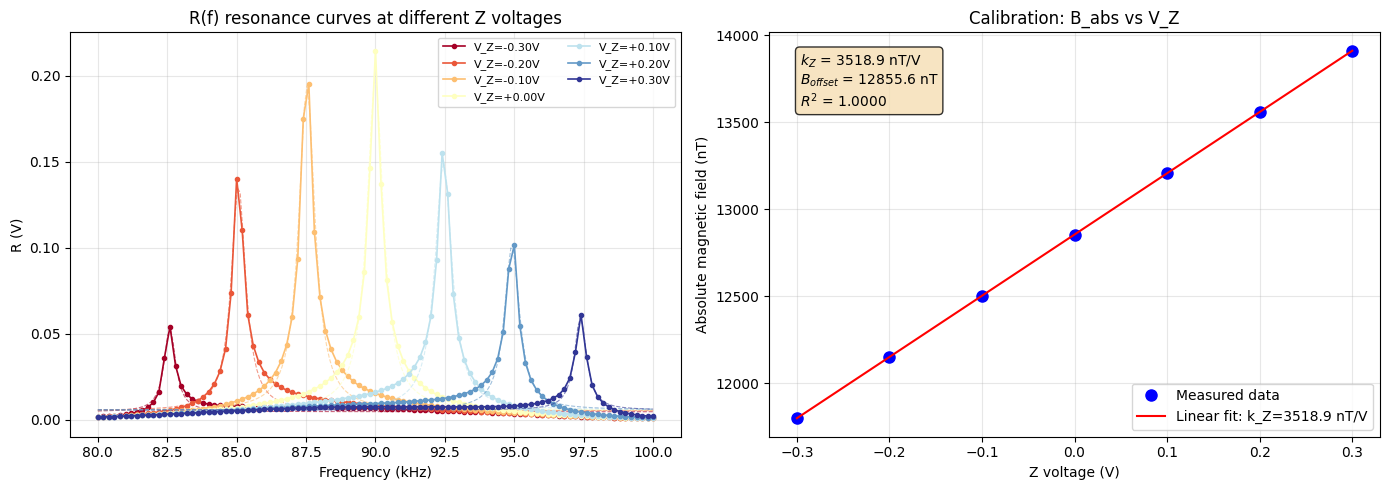

图表已保存: d:\Code\exp_agent\data\Z_Field_Calibration\0517_1839_calib\results\calibration_curves.png


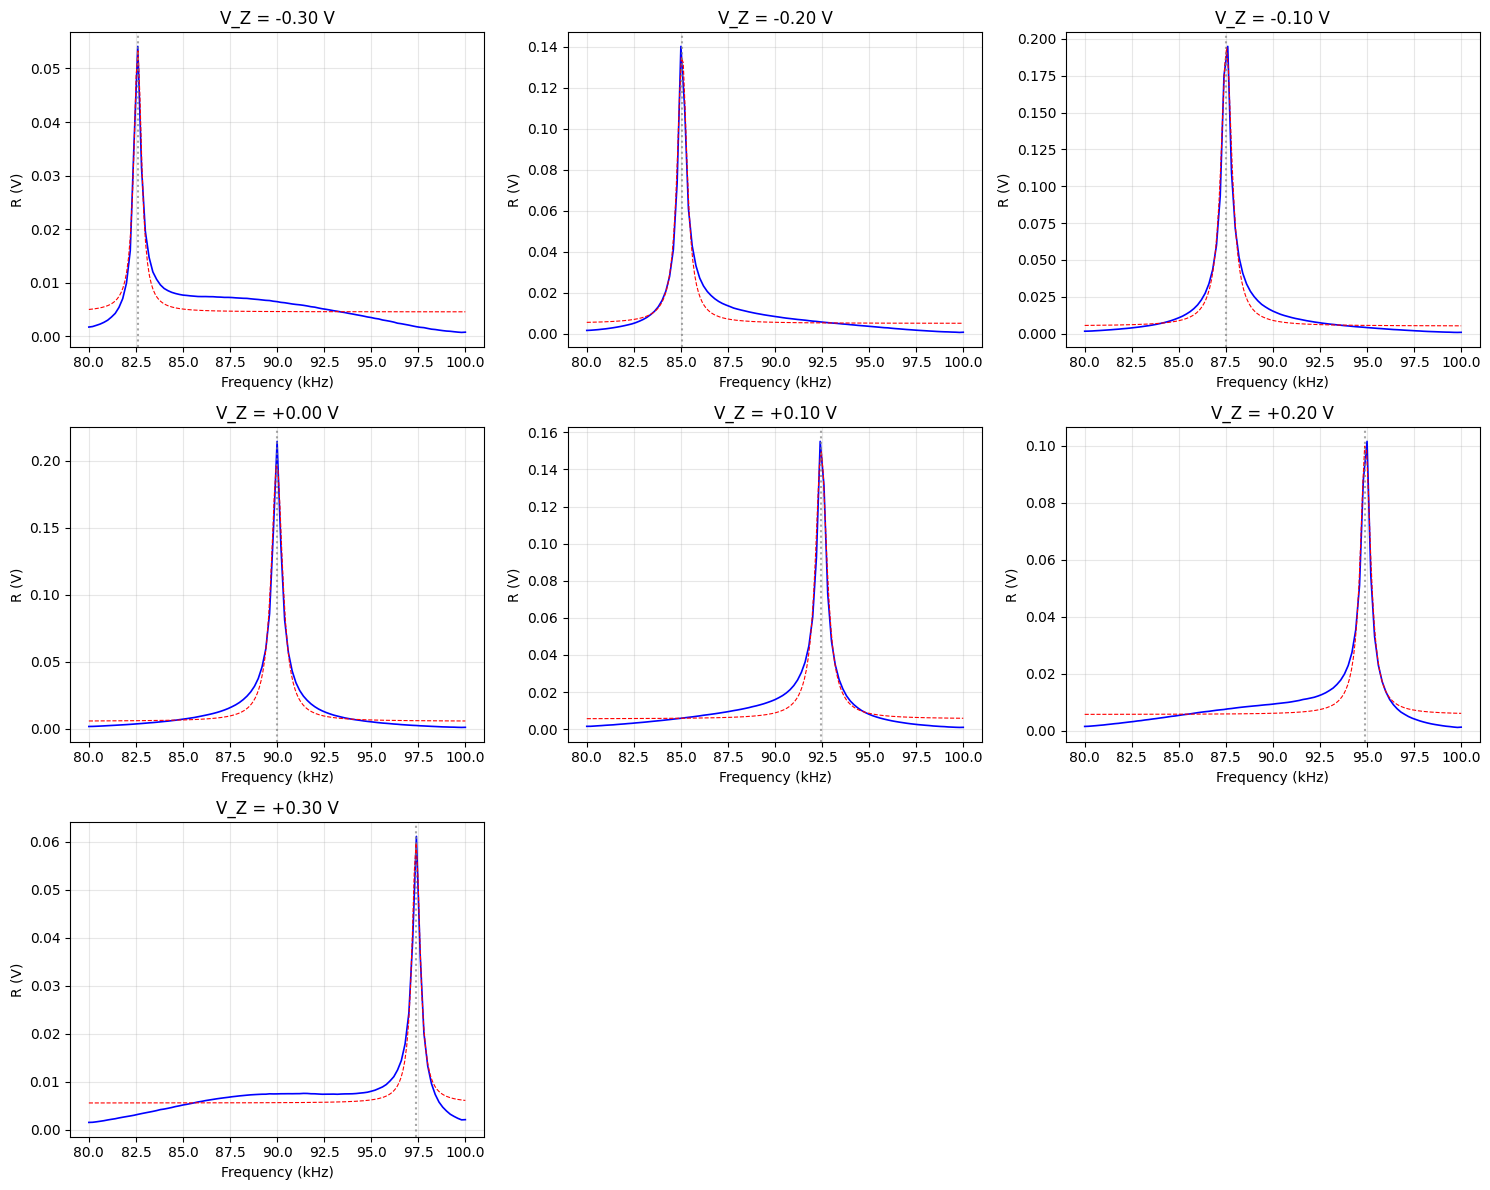

子图已保存: d:\Code\exp_agent\data\Z_Field_Calibration\0517_1839_calib\results\resonance_subplots.png


In [ ]:
# ---- 绘制结果 ----

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---------- 图 1: 各 V_Z 下的 R(f) 曲线叠加 ----------
ax1 = axes[0]
colors = plt.cm.RdYlBu(np.linspace(0, 1, len(results)))

for idx, (V_Z, data) in enumerate(sorted(results.items())):
    freqs = data["freqs"] / 1e3  # kHz
    r_vals = data["r"]
    ax1.plot(freqs, r_vals, "-o", color=colors[idx],
             markersize=3, linewidth=1.2,
             label=f"V_Z={V_Z:+.2f}V")

    # 如果拟合成功，绘出拟合曲线
    if V_Z in fit_results:
        popt = fit_results[V_Z]["popt"]
        f_fit = np.linspace(freqs[0], freqs[-1], 200)
        r_fit = lorentzian(f_fit * 1e3, *popt)
        ax1.plot(f_fit, r_fit, "--", color=colors[idx],
                 linewidth=0.8, alpha=0.6)

ax1.set_xlabel("Frequency (kHz)")
ax1.set_ylabel("R (V)")
ax1.set_title("R(f) resonance curves at different Z voltages")
ax1.legend(fontsize=8, ncol=2)
ax1.grid(True, alpha=0.3)

# ---------- 图 2: B_abs vs V_Z 线性回归 ----------
ax2 = axes[1]

if len(V_list) >= 2:
    # 散点
    ax2.plot(V_array, B_array, "bo", markersize=8, label="Measured data")

    # 拟合直线
    V_fit = np.linspace(min(V_array), max(V_array), 100)
    B_fit = slope * V_fit + intercept
    ax2.plot(V_fit, B_fit, "r-", linewidth=1.5,
             label=f"Linear fit: k_Z={k_Z:.1f} nT/V")

    # 误差标注
    ax2.text(0.05, 0.95,
             f"$k_Z$ = {k_Z:.1f} nT/V\n"
             f"$B_{{offset}}$ = {B_offset:.1f} nT\n"
             f"$R^2$ = {R_squared:.4f}",
             transform=ax2.transAxes,
             verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

ax2.set_xlabel("Z voltage (V)")
ax2.set_ylabel("Absolute magnetic field (nT)")
ax2.set_title("Calibration: B_abs vs V_Z")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plot_path = results_dir / "calibration_curves.png"
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"图表已保存: {plot_path}")

# ---- 如果点数较多，绘制子图阵列 ----
if len(results) <= 8:
    n_cols = min(3, len(results))
    n_rows = int(np.ceil(len(results) / n_cols))
    fig2, axes2 = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes2 = axes2.flatten() if n_rows * n_cols > 1 else [axes2]

    for idx, (V_Z, data) in enumerate(sorted(results.items())):
        ax = axes2[idx]
        freqs = data["freqs"] / 1e3
        r_vals = data["r"]

        ax.plot(freqs, r_vals, "b-", linewidth=1.2)
        if V_Z in fit_results:
            popt = fit_results[V_Z]["popt"]
            f_fit = np.linspace(freqs[0], freqs[-1], 200)
            r_fit = lorentzian(f_fit * 1e3, *popt)
            ax.plot(f_fit, r_fit, "r--", linewidth=0.8)
            ax.axvline(x=popt[1]/1e3, color="gray", linestyle=":", alpha=0.7)

        ax.set_xlabel("Frequency (kHz)")
        ax.set_ylabel("R (V)")
        ax.set_title(f"V_Z = {V_Z:+.2f} V")
        ax.grid(True, alpha=0.3)

    for idx in range(len(results), len(axes2)):
        axes2[idx].set_visible(False)

    plt.tight_layout()
    subplot_path = results_dir / "resonance_subplots.png"
    fig2.savefig(subplot_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"子图已保存: {subplot_path}")

## 11. 🔒 安全断开设备

In [ ]:
# ---- 断开所有设备（保持输出状态不变） ----

print("正在断开设备...")
print("（所有设备输出状态保持当前设置不变）")

# 仅断开连接，不改变任何输出状态
for name, dev in devices.items():
    if hasattr(dev, "disconnect"):
        try:
            dev.disconnect()
            print(f"  {name} 已断开")
        except Exception as e:
            print(f"  {name} 断开失败: {e}")

print("所有设备已断开")

正在安全断开设备...
  gs200 已断开
  dg_sweep 已断开
  dg_laser 已断开
  dg_comp 已断开
  dg_mod 已断开
  dg_temp 已断开
所有设备已安全断开
